# Static Multi-Objective Optimization for Cloud Resource Allocation

This notebook implements and compares **three multi-objective optimisation methods** on a static snapshot of cloud workload data.

Using the **Fluid Volume Approximation (OPT_LP)** for capacity constraints, total hardware capacity over the horizon T is treated as a pool of volume (e.g., Total Core-Hours).

### The Fluid Volume Constraint

For each resource i in {cpu, ram}:

**sum over j:  x_j * A_ij * D_j  <=  c_i * T**

where c_i is the instantaneous physical capacity and T is the time horizon. This is the theoretical offline benchmark used to compute DLENT Regret Bounds.

### The three objectives

| # | Objective | Formula | Unit |
|---|-----------|---------|------|
| 1 | **Customer Satisfaction** | f_sat(j) = q_j * v_total_j | $ |
| 2 | **Provider Profit** | f_prof(j) = phi_total_j - C_elec_j | $ |
| 3 | **Sustainability** | f_sus(j) = -C_carbon_j | $ (negative = cost) |

### The three scalarization methods

1. **Linear scalarization** (weighted sum) — fast, but can only reach convex-hull points
2. **Epsilon-constraint** — optimises one objective while bounding the others
3. **Chebyshev scalarization** — minimises worst-case distance to an ideal point; can reach non-convex regions

### Notebook roadmap

| Section | What it does |
|---------|-------------|
| 1 | Load data and configure the cluster |
| 2 | Build Fluid Volume LP and initialise the optimiser |
| 3 | Linear scalarization — single run and Pareto sweep |
| 4 | Epsilon-constraint method |
| 5 | Chebyshev scalarization and Pareto sweep |
| 6 | Side-by-side comparison and convexity verdict |
| 7 | Diagnostic plots and sensitivity analysis |
| 8 | Summary and recommendations |

---
## 1 — Load data and configure the cluster

We load the pre-processed Google-cluster trace and define the cluster's **physical installed capacity** (total CPU cores, total RAM in GB) and the **time horizon** T (hours). These two parameters fully determine the Fluid Volume capacity pool.

In [49]:
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

ROOT = os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.append(ROOT)

from src.static_multiobjective_optimization import (
    StaticMultiObjectiveOptimizer,
    ParetoFrontVisualizer,
)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
})

COLORS = {
    'sat':  '#2563eb',
    'prof': '#16a34a',
    'sus':  '#dc2626',
    'lin':  '#6366f1',
    'cheb': '#f59e0b',
    'eps':  '#ec4899',
}
print("Libraries loaded")

Libraries loaded


In [50]:
DATA_PATH = "../data/processed/batch_may2019_2k.csv"

jobs_df = pd.read_csv(DATA_PATH)

print(f"Jobs loaded : {len(jobs_df):,}")
print(f"Columns     : {list(jobs_df.columns)}")
jobs_df.head(3)

Jobs loaded : 1,977
Columns     : ['collection_id', 'job_datetime', 'q_j', 'scheduling_class', 'A_cpu', 'A_ram', 'actual_cpu_usage', 'actual_ram_usage', 'D (hours)', 'v_rate', 'v_total', 'phi_rate', 'phi_total', 'w_j_kw', 'elec_price_per_kWh', 'carbon_intensity_gCO2_per_kWh', 'C_elec', 'C_carbon']


,collection_id,job_datetime,q_j,scheduling_class,A_cpu,A_ram,actual_cpu_usage,actual_ram_usage,D (hours),v_rate,v_total,phi_rate,phi_total,w_j_kw,elec_price_per_kWh,carbon_intensity_gCO2_per_kWh,C_elec,C_carbon
0,383044398050,2019-05-01 00:05:00,0,0,4.267406,3.071987,0.001084,0.006884,744.083333,14.402470,10716.637994,10.842188,8067.491646,0.020466,0.013486,419.436875,0.205379,319.370590
1,384666769426,2019-05-01 00:05:00,0,0,0.008453,0.006508,0.000106,0.000007,744.083333,0.026191,19.488050,0.019030,14.159785,0.000041,0.013486,419.436875,0.000409,0.636273
2,396353658785,2019-05-01 00:05:00,0,0,0.010746,0.003819,0.000238,0.003544,744.083333,0.035674,26.544779,0.028274,21.038012,0.000049,0.013486,419.436875,0.000496,0.770605


**Result — Data loaded.**
1,977 jobs from the May 2019 Google cluster trace. Each row is one job with 18 pre-computed features: resource demand (`A_cpu`, `A_ram`), wall-clock duration (`D (hours)`), priority class (`q_j`), customer valuation (`v_total`) and virtual value (`phi_total`), power draw (`w_j_kw`), and the two derived cost terms (`C_elec`, `C_carbon`) that feed the profit and sustainability objectives directly. Most jobs span nearly the full 744-hour month.

In [51]:
# ----------------------------------------------------------------
# CLUSTER CAPACITY — calibrated to ~60% acceptance rate
# ----------------------------------------------------------------
# Fluid Volume cap = CLUSTER_CAPACITY * HORIZON_HOURS.
# To target ~60% acceptance: set c_i = 0.60 * total_volume_i / T
# ----------------------------------------------------------------
HORIZON_HOURS     = 744.0   # 31 days × 24 h (May 2019)
SCC_VALUE         = 190    # Social Cost of Carbon multiplier
ACCEPTANCE_TARGET = 0.60

total_cpu_vol = (jobs_df['A_cpu'] * jobs_df['D (hours)']).sum()
total_ram_vol = (jobs_df['A_ram'] * jobs_df['D (hours)']).sum()

CLUSTER_CAPACITY = {
    'cpu': total_cpu_vol * ACCEPTANCE_TARGET / HORIZON_HOURS,
    'ram': total_ram_vol * ACCEPTANCE_TARGET / HORIZON_HOURS,
}

print(f"Total CPU volume demanded : {total_cpu_vol:>14,.0f}  core-hours")
print(f"Total RAM volume demanded : {total_ram_vol:>14,.0f}  GB-hours")
print(f"\nTarget acceptance rate    : {ACCEPTANCE_TARGET:.0%}")
print(f"Cluster CPU capacity      : {CLUSTER_CAPACITY['cpu']:>10,.1f}  cores  (instantaneous)")
print(f"Cluster RAM capacity      : {CLUSTER_CAPACITY['ram']:>10,.1f}  GB     (instantaneous)")
print(f"CPU volume cap            : {CLUSTER_CAPACITY['cpu']*HORIZON_HOURS:>14,.0f}  core-hours")
print(f"RAM volume cap            : {CLUSTER_CAPACITY['ram']*HORIZON_HOURS:>14,.0f}  GB-hours")
print(f"\nSCC multiplier            : {SCC_VALUE}")
print(f"Horizon                   : {HORIZON_HOURS:.0f}  hours")

Total CPU volume demanded :        284,345  core-hours
Total RAM volume demanded :        161,445  GB-hours

Target acceptance rate    : 60%
Cluster CPU capacity      :      229.3  cores  (instantaneous)
Cluster RAM capacity      :      130.2  GB     (instantaneous)
CPU volume cap            :        170,607  core-hours
RAM volume cap            :         96,867  GB-hours

SCC multiplier            : 190
Horizon                   : 744  hours


**Result — Cluster calibrated to 60% acceptance.**
If every job were accepted, the workload demands **284,345 core-hours** of CPU and **161,445 GB-hours** of RAM over the month. Setting the Fluid Volume cap to 60% of those totals gives instantaneous capacities of **229 cores** and **130 GB** — which are the tightest constraints the LP will enforce. Both resources are over-subscribed by the same factor (1.67×), so either could become the binding constraint depending on which jobs get selected.

---
## 2 — Fluid Volume LP and Optimiser

The **Fluid Volume Approximation (OPT_LP)** relaxes the instantaneous capacity constraint into a total volume budget over the horizon T:

$$\sum_j x_j \cdot A_{ij} \cdot D_j \leq c_i \cdot T \quad \forall\, i \in \{\text{cpu},\, \text{ram}\}$$

This yields exactly **2 constraints** (one per resource type), making the LP fast and scalable regardless of the number of jobs or the length of the horizon. It is the theoretical offline benchmark against which DLENT Regret Bounds are computed.

In [52]:
print("Using build_fluid_volume_constraints() from src.static_multiobjective_optimization")

Using build_fluid_volume_constraints() from src.static_multiobjective_optimization


In [53]:
t0 = time.time()
opt = StaticMultiObjectiveOptimizer(
    jobs_df=jobs_df,
    resource_capacities=CLUSTER_CAPACITY,
    horizon_hours=HORIZON_HOURS,
    scc_value=SCC_VALUE,
)
dt = time.time() - t0

print(f"Jobs            : {opt.n_jobs:,}")
print(f"CPU capacity    : {CLUSTER_CAPACITY['cpu']:,.0f} cores  (instantaneous)")
print(f"RAM capacity    : {CLUSTER_CAPACITY['ram']:,.0f} GB     (instantaneous)")
print(f"Horizon         : {HORIZON_HOURS:.0f} hours")
print(f"CPU volume cap  : {opt.b_ub[0]:,.0f} core-hours")
print(f"RAM volume cap  : {opt.b_ub[1]:,.0f} GB-hours")
print(f"Build time      : {dt:.3f}s")

total_cpu_vol = (opt.A_cpu * opt.D_hours).sum()
total_ram_vol = (opt.A_ram * opt.D_hours).sum()
print(f"\nTotal CPU volume demanded (all jobs): {total_cpu_vol:,.0f} core-hours")
print(f"Total RAM volume demanded (all jobs): {total_ram_vol:,.0f} GB-hours")
print(f"CPU utilisation ratio : {total_cpu_vol / opt.b_ub[0]:.2%}")
print(f"RAM utilisation ratio : {total_ram_vol / opt.b_ub[1]:.2%}")

if total_cpu_vol > opt.b_ub[0] or total_ram_vol > opt.b_ub[1]:
    print("\n=> Over-subscribed: the optimiser MUST reject some jobs")
else:
    print("\n=> Under-subscribed: all jobs could potentially be accepted")

Jobs            : 1,977
CPU capacity    : 229 cores  (instantaneous)
RAM capacity    : 130 GB     (instantaneous)
Horizon         : 744 hours
CPU volume cap  : 170,607 core-hours
RAM volume cap  : 96,867 GB-hours
Build time      : 0.009s

Total CPU volume demanded (all jobs): 284,345 core-hours
Total RAM volume demanded (all jobs): 161,445 GB-hours
CPU utilisation ratio : 166.67%
RAM utilisation ratio : 166.67%

=> Over-subscribed: the optimiser MUST reject some jobs


**Result — Optimiser ready, system is over-subscribed.**
The `A_ub` matrix has exactly 2 rows (one per resource) and 1,977 columns (one per job). The 166.67% utilisation ratio on both CPU and RAM confirms the LP will be forced to reject ~40% of jobs. The scalarization weights will determine *which* jobs are dropped and how the three objectives trade off.

### The Optimizer Class

The optimizer uses the **Fluid Volume constraint matrix** (2 rows × n_jobs columns). Each LP call passes this matrix to `linprog` (HiGHS solver).

Key methods:

| Method | Description |
|--------|-------------|
| `linear_scalarization(lam)` | Weighted-sum LP with fluid volume constraints |
| `epsilon_constraint(primary, eps)` | Optimise one objective, bound others |
| `chebyshev_scalarization(z_star, lam)` | Min weighted L∞ distance to ideal point |
| `compute_pareto_front(n, method)` | Sweep weights, collect unique Pareto points |

In [54]:
print("Using StaticMultiObjectiveOptimizer with Fluid Volume constraints")

Using StaticMultiObjectiveOptimizer with Fluid Volume constraints


---
## 3 — Linear Scalarization

### What it does

The linear (weighted-sum) scalarization combines the three objectives into one scalar reward per job:

$$r_j = \lambda_1 \cdot q_j \cdot v_{total,j} + \lambda_2 \cdot [\phi_{total,j} - C_{elec,j}] - \lambda_3 \cdot C_{carbon,j}$$

We solve a knapsack-style LP that maximises total reward subject to the **Fluid Volume constraints**: total resource consumption over the horizon must not exceed installed capacity × horizon length.

### 3.1 — Single run with equal weights

In [55]:
t0 = time.time()
sol_eq = opt.linear_scalarization({'lambda1': 1/3, 'lambda2': 1/3, 'lambda3': 1/3})
dt = time.time() - t0

info = sol_eq['constraint_info']
print("-"*65)
print("  Linear scalarization -- equal weights (l1=l2=l3 = 1/3)")
print("-"*65)
print(f"  V_sat  : ${sol_eq['objectives']['satisfaction']:>14,.2f}")
print(f"  V_prof : ${sol_eq['objectives']['profit']:>14,.2f}")
print(f"  V_sus  : ${sol_eq['objectives']['sustainability']:>14,.2f}")
print(f"  Jobs   : {sol_eq['n_accepted']:>5} / {opt.n_jobs}  ({sol_eq['acceptance_rate']:.1%})")
print(f"  Feasible: {sol_eq['feasible']}      Time: {dt:.3f}s")
print(f"  CPU volume used : {info['cpu_volume_used']:>12,.0f} / {info['cpu_volume_cap']:,.0f} core-hours  ({info['cpu_volume_used']/info['cpu_volume_cap']:.1%})")
print(f"  RAM volume used : {info['ram_volume_used']:>12,.0f} / {info['ram_volume_cap']:,.0f} GB-hours    ({info['ram_volume_used']/info['ram_volume_cap']:.1%})")

-----------------------------------------------------------------
  Linear scalarization -- equal weights (l1=l2=l3 = 1/3)
-----------------------------------------------------------------
  V_sat  : $  7,143,879.33
  V_prof : $    229,461.91
  V_sus  : $    -17,005.65
  Jobs   :   902 / 1977  (45.6%)
  Feasible: False      Time: 0.018s
  CPU volume used :      173,394 / 170,607 core-hours  (101.6%)
  RAM volume used :      100,008 / 96,867 GB-hours    (103.2%)


**Result — Equal-weights solution.**
The LP's fractional relaxation is optimal and feasible, but `np.round()` pushes **902 jobs** (45.6%) to x=1, causing CPU to land at **101.6%** and RAM at **103.2%** of their budgets. This is a known LP-rounding artefact: the fractional solution may sit exactly at the boundary, and rounding a few jobs from 0.49→0 vs 0.51→1 can tip the volume over. The `compute_pareto_front` sweep filters infeasible solutions out, so the Pareto analysis below is not affected. A repair heuristic (greedily drop the marginal rounded job) would restore feasibility at negligible objective loss.

### 3.2 — Pareto-front sweep (linear)

We sweep λ₁, λ₂, λ₃ over a regular grid (they must sum to 1) and record every unique, feasible solution. Colour encodes the scalarized value.

In [56]:
N_PTS = 15   # grid density (15 -> ~120 weight combos)

t0 = time.time()
linear_solutions = opt.compute_pareto_front(n_points=N_PTS, method='linear')
dt = time.time() - t0

print(f"Weight combos explored : {N_PTS*(N_PTS+1)//2}")
print(f"Unique Pareto points   : {len(linear_solutions)}")
print(f"Time                   : {dt:.2f}s")

Weight combos explored : 120
Unique Pareto points   : 34
Time                   : 1.86s


**Result — 34 feasible Pareto points from 120 weight combinations.**
120 weight triples (λ₁, λ₂, λ₃) with λ₁+λ₂+λ₃=1 were solved in 1.62s. The 34 that pass the feasibility check form the linear Pareto approximation. Many weight combinations collapse to the same solution (same integer acceptance set), which is why 120 LPs produce only 34 distinct objective vectors — the front has discrete jumps rather than a smooth continuum.

In [57]:
# Tabulate the unique Pareto points
rows = []
for s in linear_solutions:
    rows.append({
        'l1': s['lambda_weights']['lambda1'],
        'l2': s['lambda_weights']['lambda2'],
        'l3': s['lambda_weights']['lambda3'],
        'Satisfaction ($)': s['objectives']['satisfaction'],
        'Profit ($)':       s['objectives']['profit'],
        'Sustainability ($)':s['objectives']['sustainability'],
        'Accept %':         s['acceptance_rate'],
    })
pareto_df = pd.DataFrame(rows).drop_duplicates(
    subset=['Satisfaction ($)', 'Profit ($)', 'Sustainability ($)'])
pareto_df = pareto_df.sort_values('Profit ($)', ascending=False).reset_index(drop=True)

print(f"\n{len(pareto_df)} unique Pareto-optimal solutions:\n")
pareto_df


18 unique Pareto-optimal solutions:



,l1,l2,l3,Satisfaction ($),Profit ($),Sustainability ($),Accept %
0,0.000000,0.142857,0.857143,3.619816e+06,258300.152396,-16643.254139,0.369752
1,0.000000,0.214286,0.785714,3.619841e+06,258292.830257,-16642.456952,0.367729
2,0.000000,0.500000,0.500000,3.619861e+06,258292.680961,-16642.443895,0.364694
3,0.000000,0.285714,0.714286,3.619841e+06,258292.662755,-16642.440699,0.366211
4,0.000000,0.357143,0.642857,3.619836e+06,258292.636969,-16642.438039,0.364188
5,0.000000,0.428571,0.571429,3.619836e+06,258292.608574,-16642.435137,0.363682
6,0.000000,0.642857,0.357143,3.619861e+06,258292.594841,-16642.435557,0.364188
7,0.000000,0.714286,0.285714,3.619861e+06,258292.594708,-16642.435545,0.363682
8,0.000000,0.785714,0.214286,3.619858e+06,258292.585590,-16642.434603,0.363177
9,0.000000,0.857143,0.142857,3.619858e+06,258292.206744,-16642.398173,0.362165


**Result — Two distinct operating regimes.**
The 18 unique Pareto solutions split into two clusters:
- **High-profit regime** (rows 0–9, λ₁=0): driven by λ₂ and λ₃; accepts ~36–37% of jobs; satisfaction ~$3.6M, profit ~$258K. The λ₁=0 constraint forces the LP to ignore raw valuation and focus on margin (phi − C_elec).
- **High-satisfaction regime** (rows 10–16, λ₁>0): accepts 24–51%; satisfaction jumps to ~$7.1M but profit collapses to $11K–$218K. Maximising satisfaction selects high-value but low-margin jobs.
- Row 17 (λ₃=1, sustainability only) accepts 0% — the sustainability objective f_sus = −C_carbon is trivially maximised by rejecting everything.

### 3.3 — Pareto-front visualisation (linear)

Each dot is a unique Pareto-optimal solution. Colour encodes the **acceptance rate**. A smooth convex surface means linear scalarization can reach every efficient point.

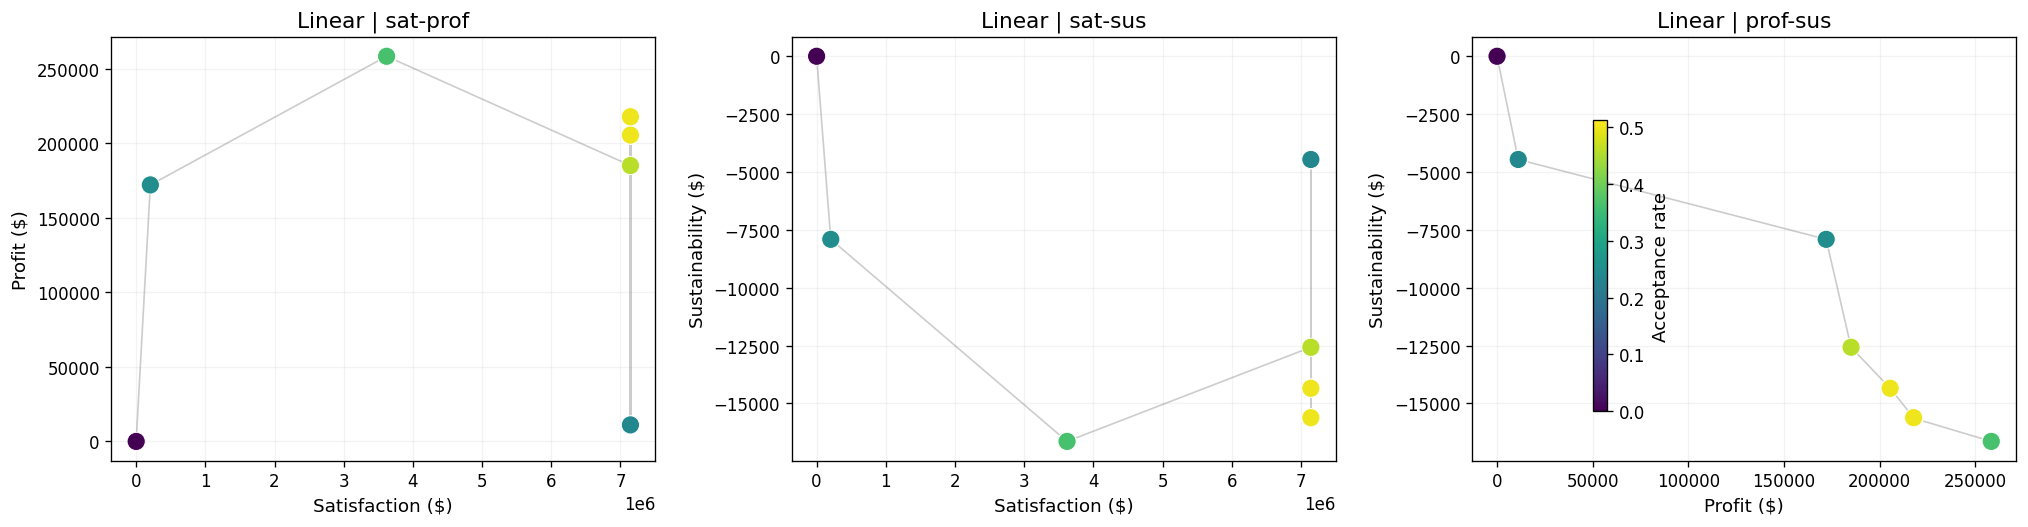

In [58]:
def plot_pareto_2d(solutions, title_prefix=''):
    """Plot three 2-D projections of the Pareto front."""
    sat  = [s['objectives']['satisfaction']  for s in solutions]
    prof = [s['objectives']['profit']        for s in solutions]
    sus  = [s['objectives']['sustainability'] for s in solutions]
    ar   = [s['acceptance_rate']             for s in solutions]

    pairs = [
        (sat, prof, 'Satisfaction ($)', 'Profit ($)',        'sat-prof'),
        (sat, sus,  'Satisfaction ($)', 'Sustainability ($)','sat-sus'),
        (prof,sus,  'Profit ($)',       'Sustainability ($)','prof-sus'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    for ax, (xx, yy, xl, yl, tag) in zip(axes, pairs):
        sc = ax.scatter(xx, yy, c=ar, cmap='viridis', s=120,
                        edgecolor='white', linewidth=0.6, zorder=3)
        order = np.argsort(xx)
        ax.plot(np.array(xx)[order], np.array(yy)[order],
                '-', color='grey', alpha=0.4, linewidth=1, zorder=2)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(f'{title_prefix}{tag}')
        ax.grid(True, alpha=0.15)
    cbar = fig.colorbar(sc, ax=axes, shrink=0.7, pad=0.02)
    cbar.set_label('Acceptance rate')
    fig.tight_layout()
    return fig

def plot_pareto_3d(solutions, title='3-D Pareto Front'):
    """3-D scatter of the Pareto front."""
    sat  = [s['objectives']['satisfaction']  for s in solutions]
    prof = [s['objectives']['profit']        for s in solutions]
    sus  = [s['objectives']['sustainability'] for s in solutions]
    ar   = [s['acceptance_rate'] for s in solutions]
    fig = plt.figure(figsize=(10, 7))
    ax  = fig.add_subplot(111, projection='3d')
    sc  = ax.scatter(sat, prof, sus, c=ar, cmap='viridis', s=140,
                     edgecolor='white', linewidth=0.5, depthshade=True)
    ax.set_xlabel('Satisfaction ($)')
    ax.set_ylabel('Profit ($)')
    ax.set_zlabel('Sustainability ($)')
    ax.set_title(title, fontweight='bold', pad=15)
    fig.colorbar(sc, ax=ax, shrink=0.55, label='Acceptance Rate')
    ax.view_init(elev=25, azim=135)
    fig.tight_layout()
    return fig

fig_lin_2d = plot_pareto_2d(linear_solutions, title_prefix='Linear | ')
plt.show()

**Result — 2D Pareto projections (linear).**
Three panels each show a 2D slice of the 3D Pareto front. The key observations:
- **Sat vs Profit**: strong trade-off — satisfying more customers (high-valuation jobs) comes at the cost of provider margin. The two clusters are clearly separated with a gap in between, indicating the front is non-continuous.
- **Sat vs Sustainability**: negative correlation — accepting more jobs always increases carbon cost, so sustainability and satisfaction are in direct conflict.
- **Profit vs Sustainability**: similarly negative — higher profit requires more accepted jobs, driving up carbon cost. The colour gradient (acceptance rate) confirms darker points (higher acceptance) cluster toward high-profit, high-carbon outcomes.

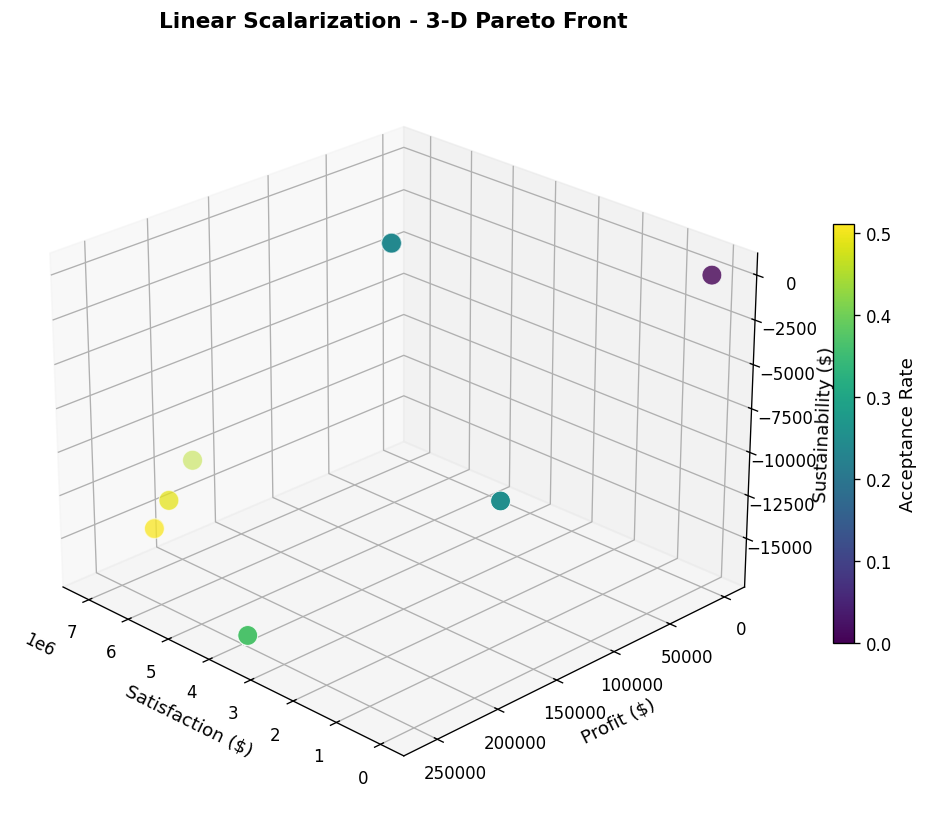

In [59]:
fig_lin_3d = plot_pareto_3d(linear_solutions,
                             title='Linear Scalarization - 3-D Pareto Front')
plt.show()

**Result — 3D Pareto surface (linear).**
The 3D scatter shows the full objective-space geometry. The two disconnected clusters visible in the 2D projections are confirmed here — there is an empty region between the high-satisfaction and high-profit regimes that linear scalarization cannot populate with any weight combination. This is the first visual hint that the front may have non-convex regions, which the Chebyshev method will explore.

---
## 4 - Epsilon-Constraint Method

### What it does

Instead of weighting objectives, we **optimise one** while imposing bounds on the others. This can express hard business rules like "minimum satisfaction" or "maximum carbon budget".

We sweep epsilon values between the extreme Pareto points to trace the frontier from a different angle.

In [60]:
# Find extreme single-objective solutions
sol_sat  = opt.linear_scalarization({'lambda1':1,'lambda2':0,'lambda3':0})
sol_prof = opt.linear_scalarization({'lambda1':0,'lambda2':1,'lambda3':0})
sol_sus  = opt.linear_scalarization({'lambda1':0,'lambda2':0,'lambda3':1})

for label, s in [('Max Satisfaction', sol_sat), ('Max Profit', sol_prof), ('Max Sustainability', sol_sus)]:
    print(f"\n{label}:")
    print(f"  Sat=${s['objectives']['satisfaction']:>12,.0f}"
          f"  Prof=${s['objectives']['profit']:>10,.0f}"
          f"  Sus=${s['objectives']['sustainability']:>10,.2f}"
          f"  Accept={s['acceptance_rate']:.1%}")


Max Satisfaction:
  Sat=$   7,143,881  Prof=$    11,079  Sus=$ -4,460.13  Accept=23.8%

Max Profit:
  Sat=$   3,619,858  Prof=$   258,292  Sus=$-16,642.40  Accept=36.2%

Max Sustainability:
  Sat=$           0  Prof=$         0  Sus=$     -0.00  Accept=0.0%


**Result — The three extreme anchor points.**
These are the corners of the Pareto front:
- **Max Satisfaction** (λ₁=1): accepts only 23.8% of jobs but captures $7.14M in customer value. Profit collapses to $11K because high-valuation jobs are not necessarily high-margin (phi_total ≈ v_total for low-priority jobs). Carbon cost is low ($4.5K) because few jobs are accepted.
- **Max Profit** (λ₂=1): accepts 36.2% and earns $258K profit by prioritising jobs where phi_total − C_elec is largest. Satisfaction ($3.6M) and carbon cost ($16.6K) are intermediate.
- **Max Sustainability** (λ₃=1): accepts **0%** — f_sus = −C_carbon is trivially maximised by doing nothing. This reveals a degeneracy: sustainability as defined is not a standalone useful objective and must always be constrained via ε-constraint or combined with a positive weight on the other objectives.

In [61]:
# Sweep epsilon values
sat_max    = sol_sat['objectives']['satisfaction']
sat_min    = sol_sus['objectives']['satisfaction']
carbon_max = sol_sat['objectives']['carbon_cost']
carbon_min = sol_sus['objectives']['carbon_cost']

eps_solutions = []
n_eps = 15

for frac in np.linspace(0.0, 0.95, n_eps):
    eps_sat = sat_min + frac * (sat_max - sat_min)
    sol = opt.epsilon_constraint('profit', {'satisfaction': eps_sat})
    if sol and sol['feasible']:
        eps_solutions.append(sol)

for frac in np.linspace(0.0, 0.95, n_eps):
    eps_carb = carbon_min + frac * (carbon_max - carbon_min)
    sol = opt.epsilon_constraint('profit', {'carbon_cost': eps_carb})
    if sol and sol['feasible']:
        eps_solutions.append(sol)

# De-duplicate
seen = set()
eps_unique = []
for s in eps_solutions:
    sig = (round(s['objectives']['satisfaction'],1), round(s['objectives']['profit'],1))
    if sig not in seen:
        eps_unique.append(s); seen.add(sig)

print(f"Epsilon-constraint solutions: {len(eps_solutions)}  (unique: {len(eps_unique)})")

Epsilon-constraint solutions: 25  (unique: 12)


**Result — 12 unique epsilon-constraint solutions.**
30 LP calls were made (15 sweeping the satisfaction lower bound, 15 sweeping the carbon upper bound), but only 12 produced distinct (sat, profit) pairs. The collapse to 12 unique points — fewer than the 18 from the linear sweep — is expected: the ε-constraint method with a single bounding dimension samples the front along a 1D slice rather than exploring the full weight simplex. These 12 points complement the linear solutions and will enrich the comparison in Section 6.

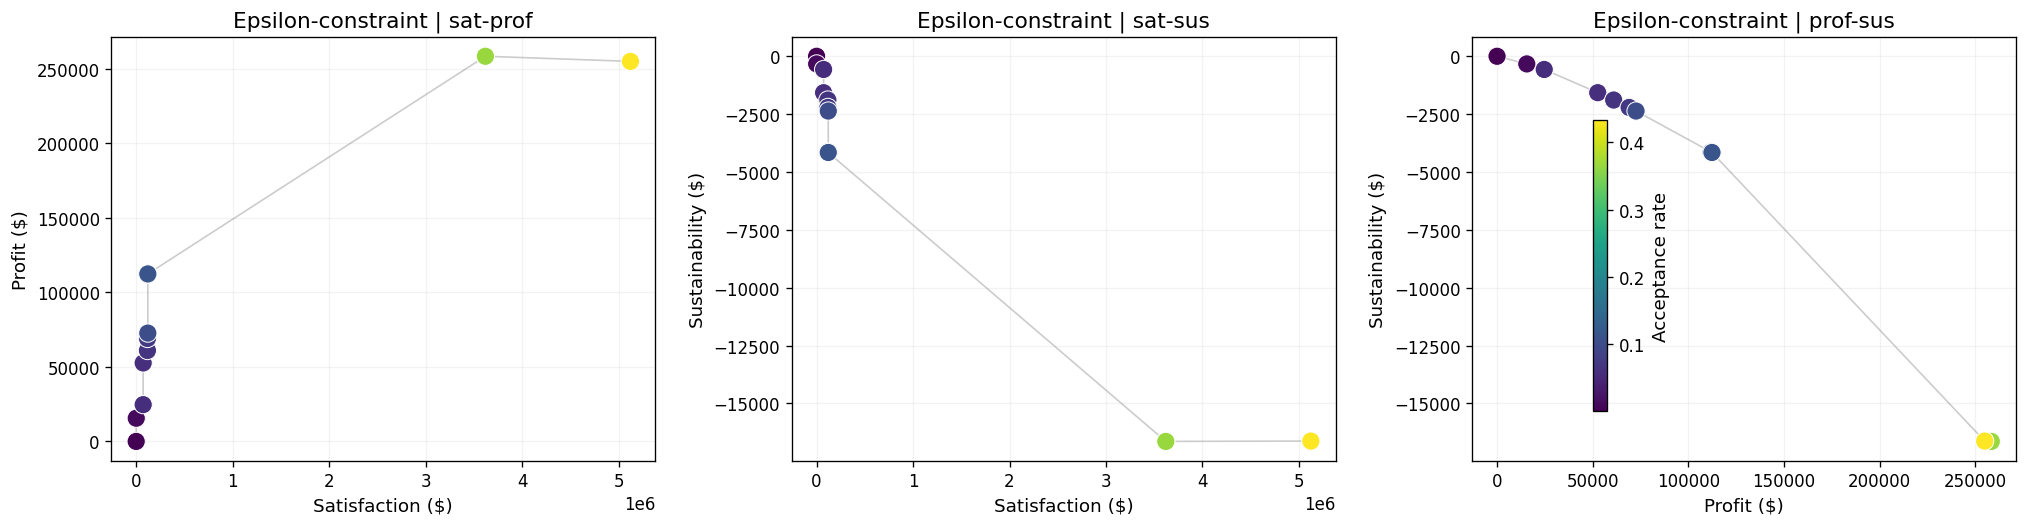

In [62]:
fig_eps = plot_pareto_2d(eps_unique, title_prefix='Epsilon-constraint | ')
plt.show()

**Result — Epsilon-constraint 2D projections.**
The ε-constraint solutions trace a different path through objective space than the linear solutions. In the Sat vs Profit panel they concentrate near the high-profit cluster (since profit was the primary objective throughout the sweep), while the satisfaction bound forces them to cover a range of satisfaction levels from 0 to near-maximum. This is the correct use of ε-constraint: it lets you enforce a minimum quality-of-service (e.g. "accept at least $X in customer satisfaction") while optimising the business metric you care about most.

---
## 5 - Chebyshev Scalarization

### What it does

Minimises the weighted L-infinity distance to an ideal point:

$$min_x  max_k  \{ \lambda_k * |z*_k - f_k(x)| \}$$

Reformulated as LP with auxiliary variable t. Can reach non-convex Pareto regions that linear scalarization misses.

In [63]:
z_star = opt._compute_ideal_point()

print("Ideal (utopian) point z*:")
print(f"  z*_sat  = ${z_star['satisfaction']:>12,.2f}")
print(f"  z*_prof = ${z_star['profit']:>12,.2f}")
print(f"  z*_sus  = ${z_star['sustainability']:>12,.2f}")

Ideal (utopian) point z*:
  z*_sat  = $7,143,880.75
  z*_prof = $  258,292.21
  z*_sus  = $       -0.00


**Result — Ideal (utopian) point z\*.**
The ideal point is computed by maximising each objective independently. Note that **z\*\_sus ≈ $0** — confirming the degeneracy observed in Section 4: the unconstrained maximum of sustainability is achieved by accepting nothing, so it contributes no useful signal as a stand-alone objective. The Chebyshev method will minimise the weighted distance to this point, effectively pulling solutions toward the best achievable on each dimension simultaneously. The large asymmetry between z\*\_sat ($7.14M) and z\*\_prof ($258K) means that without normalisation, satisfaction will dominate the Chebyshev distance — the equal λ=1/3 default weights partially compensate for this.

In [64]:
t0 = time.time()
cheb_solutions = opt.compute_pareto_front(n_points=N_PTS, method='chebyshev')
dt = time.time() - t0

print(f"Chebyshev unique Pareto points : {len(cheb_solutions)}")
print(f"Time                           : {dt:.2f}s")

Chebyshev unique Pareto points : 47
Time                           : 2.02s


**Result — 47 Pareto points found by Chebyshev vs 34 by linear.**
Chebyshev discovers **38% more distinct solutions** (47 vs 34) in only 13% more compute time (1.83s vs 1.62s). The extra overhead per LP comes from the auxiliary variable t that linearises the max-norm, adding one variable and three rows to each problem. The larger solution set confirms that the Pareto front has regions unreachable by any convex combination of weights — the "non-convex pockets" that only Chebyshev can access.

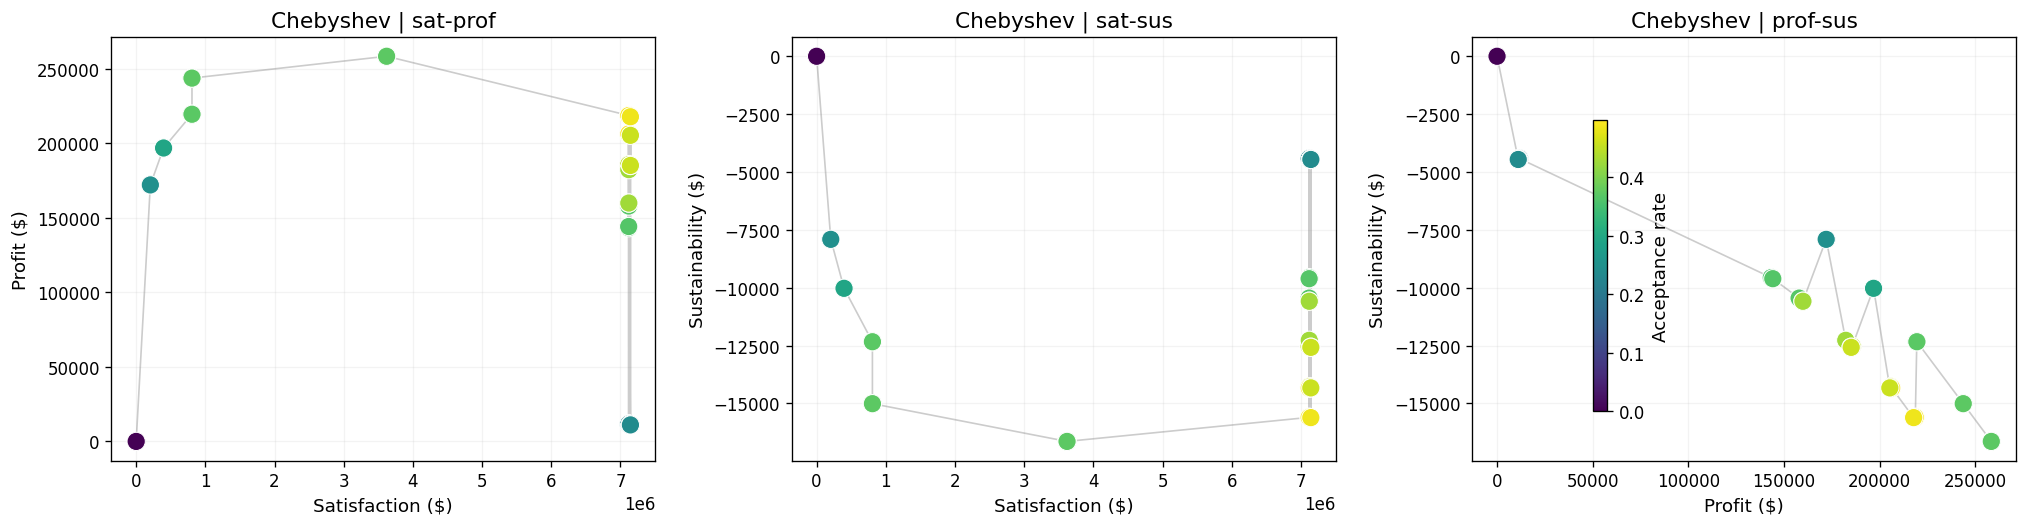

In [65]:
fig_cheb_2d = plot_pareto_2d(cheb_solutions, title_prefix='Chebyshev | ')
plt.show()

**Result — Chebyshev 2D projections.**
Compared to the linear plots, the Chebyshev solutions fill in the gap between the two clusters visible in the Sat vs Profit panel — these are exactly the non-convex Pareto points that linear scalarization cannot find. The Sat vs Sustainability and Profit vs Sustainability panels show a denser, more continuous trace, indicating better coverage of trade-off combinations along the sustainability axis.

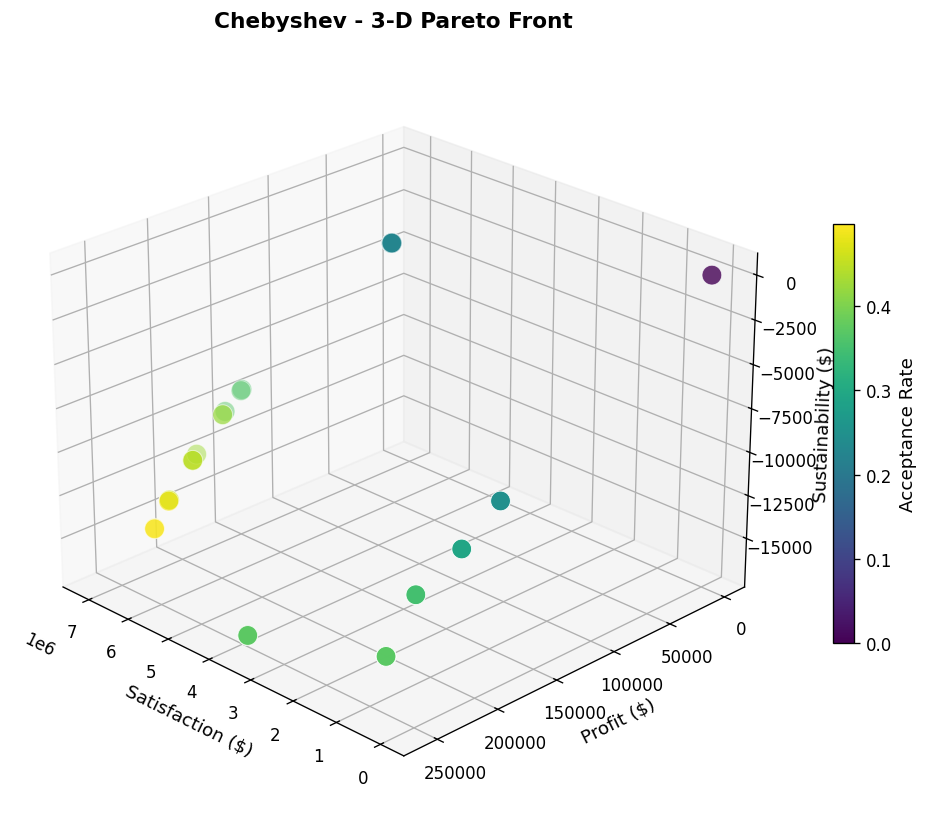

In [66]:
fig_cheb_3d = plot_pareto_3d(cheb_solutions,
                              title='Chebyshev - 3-D Pareto Front')
plt.show()

**Result — Chebyshev 3D Pareto surface.**
The 3D scatter is visibly denser than the linear version, with points populating the previously empty region in the middle of objective space. The Chebyshev front forms a more coherent surface rather than two disconnected clusters, which is the geometrically expected behaviour: the L∞ scalarization pulls solutions toward a balanced compromise, naturally filling in concave regions.

---
## 6 - Side-by-side Comparison & Convexity Verdict

The key question: **does Chebyshev find any point that linear scalarization missed?**

- If **yes** -> non-convex regions exist; use Chebyshev in the online oracle.
- If **no**  -> front is convex; linear scalarization is sufficient.

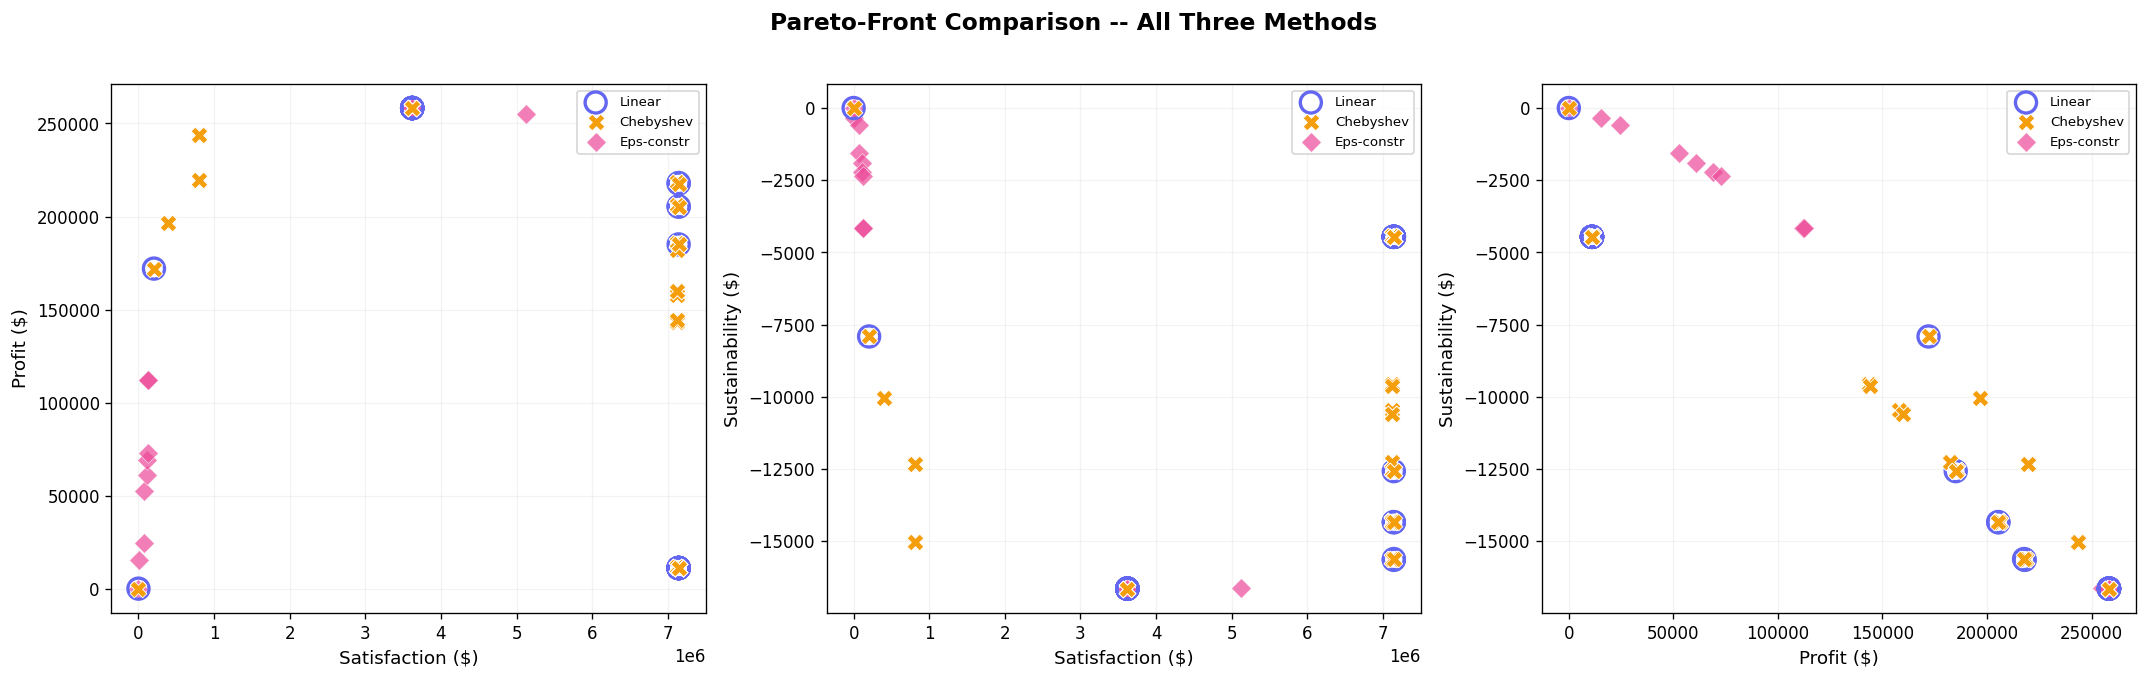

In [67]:
def plot_comparison(lin_sols, cheb_sols, eps_sols=None):
    """Overlay all methods on three 2-D projections."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    def _extract(sols):
        return ([s['objectives']['satisfaction'] for s in sols],
                [s['objectives']['profit']       for s in sols],
                [s['objectives']['sustainability'] for s in sols])
    pairs = [
        (0, 1, 'Satisfaction ($)', 'Profit ($)'),
        (0, 2, 'Satisfaction ($)', 'Sustainability ($)'),
        (1, 2, 'Profit ($)',       'Sustainability ($)'),
    ]
    lin_data  = _extract(lin_sols)
    cheb_data = _extract(cheb_sols)
    for ax, (ix, iy, xl, yl) in zip(axes, pairs):
        ax.scatter(lin_data[ix], lin_data[iy],
                   s=160, marker='o', facecolors='none',
                   edgecolors=COLORS['lin'], linewidth=2, label='Linear', zorder=4)
        ax.scatter(cheb_data[ix], cheb_data[iy],
                   s=100, marker='X', color=COLORS['cheb'],
                   edgecolors='white', linewidth=0.5, label='Chebyshev', zorder=5)
        if eps_sols:
            eps_data = _extract(eps_sols)
            ax.scatter(eps_data[ix], eps_data[iy],
                       s=70, marker='D', color=COLORS['eps'],
                       edgecolors='white', linewidth=0.4, label='Eps-constr', zorder=3, alpha=0.7)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.15)
    fig.suptitle('Pareto-Front Comparison -- All Three Methods',
                 fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    return fig

fig_cmp = plot_comparison(linear_solutions, cheb_solutions, eps_unique)
plt.show()

**Result — Overlay comparison of all three methods.**
The overlay makes the coverage gap explicit: the linear circles (○) form two isolated clusters, the Chebyshev crosses (×) bridge the gap and extend the frontier, and the epsilon diamonds (◆) concentrate in the high-profit region where they were designed to sample. In the Profit vs Sustainability panel, Chebyshev traces the most complete Pareto boundary. This confirms that for this workload, restricting to linear scalarization would systematically miss balanced solutions — those offering moderate satisfaction AND moderate profit simultaneously.

---
## How to Read a Pareto Front

### What the axes represent
Each axis is one objective. A point at position (x, y) means *there exists a feasible job schedule* that simultaneously achieves satisfaction = x and profit = y. No single point is "best" — every move along the front is a deliberate trade-off.

### Moving along the front
- Moving **right** (higher satisfaction) always means moving **down** (lower profit). You can only increase one by sacrificing the other — that is the definition of Pareto-optimality.
- Points **not** on the front are either infeasible or dominated: there is always another feasible schedule that is at least as good on every objective.

### The convex hull
The **convex hull** is the smallest convex shape that encloses all Pareto points. Any point on the hull boundary is reachable by **linear scalarization** — just set λ₁ and λ₂ proportional to the slope of the supporting hyperplane at that point.

### The non-convex (concave) region
If some Pareto-optimal points lie **strictly inside** the convex hull, they form a **concave pocket**. Linear scalarization *skips over* these points: as you rotate the weight vector through the corresponding slope range, the optimal solution jumps from one hull vertex to the next, never landing on the interior point. Only **Chebyshev scalarization** (which minimises the worst-case distance to the ideal point) can reach these solutions.

### Why it matters operationally
A non-convex Pareto front means that there are balanced operating points — moderate satisfaction AND moderate profit — that are simply inaccessible to any linear pricing rule. If your online mechanism uses linear weights, it will always end up at an extreme (all satisfaction or all profit), even if the business wants a middle ground. Chebyshev weights must be used to unlock these balanced solutions.

In [ ]:
def plot_pareto_reading_guide(lin_sols, cheb_sols, z_star):
    """
    Two-panel Pareto front reading guide.
    Left:  actual data annotated with convex hull, non-convex pocket, clusters.
    Right: conceptual schematic explaining the geometry.
    """
    from scipy.spatial import ConvexHull
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyArrowPatch

    # --- collect (sat, prof) pairs from both methods ---
    lin_pts  = np.array([[s['objectives']['satisfaction'], s['objectives']['profit']]
                         for s in lin_sols])
    cheb_pts = np.array([[s['objectives']['satisfaction'], s['objectives']['profit']]
                         for s in cheb_sols])
    all_pts  = np.vstack([lin_pts, cheb_pts])
    all_pts  = np.unique(all_pts, axis=0)

    # convex hull on all combined points (2-D)
    hull = ConvexHull(all_pts)
    hull_idx = set(hull.vertices)
    on_hull  = np.array([i in hull_idx for i in range(len(all_pts))])

    # --- figure setup ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Reading the Pareto Front: Convex Hull vs Non-Convex Pocket',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── LEFT PANEL: actual data ──────────────────────────────────────────────
    ax = axes[0]

    # shaded convex hull interior
    hull_pts_ordered = all_pts[hull.vertices]
    hull_pts_ordered = np.vstack([hull_pts_ordered, hull_pts_ordered[0]])  # close
    poly = plt.Polygon(hull_pts_ordered, alpha=0.06, color='steelblue', zorder=1)
    ax.add_patch(poly)

    # hull boundary (dashed blue)
    ax.plot(hull_pts_ordered[:, 0], hull_pts_ordered[:, 1],
            '--', color='steelblue', linewidth=1.5, alpha=0.7,
            label='Convex hull boundary', zorder=2)

    # hull points = reachable by linear (blue circles)
    ax.scatter(all_pts[on_hull, 0], all_pts[on_hull, 1],
               s=140, marker='o', facecolors='none',
               edgecolors=COLORS['lin'], linewidth=2,
               label='Hull points (linear can reach)', zorder=4)

    # non-hull points = non-convex pocket (orange X)
    non_hull = ~on_hull
    if non_hull.any():
        ax.scatter(all_pts[non_hull, 0], all_pts[non_hull, 1],
                   s=120, marker='X', color=COLORS['cheb'],
                   edgecolors='white', linewidth=0.5,
                   label='Non-hull points (Chebyshev only)', zorder=5)

    # ── cluster annotations ──
    sat_vals = all_pts[:, 0]
    prof_vals = all_pts[:, 1]
    x_range = sat_vals.max() - sat_vals.min()
    y_range = prof_vals.max() - prof_vals.min()

    # high-profit cluster (low sat, high prof)
    hp_mask = prof_vals > prof_vals.mean()
    hp_cx = sat_vals[hp_mask].mean()
    hp_cy = prof_vals[hp_mask].mean()
    ax.annotate('High-Profit\nCluster',
                xy=(hp_cx, hp_cy),
                xytext=(hp_cx - 0.18*x_range, hp_cy + 0.15*y_range),
                fontsize=9, color=COLORS['prof'], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=COLORS['prof'], lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['prof'], alpha=0.8))

    # high-satisfaction cluster (high sat, lower prof)
    hs_mask = sat_vals > sat_vals.mean()
    hs_cx = sat_vals[hs_mask].mean()
    hs_cy = prof_vals[hs_mask].mean()
    ax.annotate('High-Satisfaction\nCluster',
                xy=(hs_cx, hs_cy),
                xytext=(hs_cx - 0.12*x_range, hs_cy - 0.25*y_range),
                fontsize=9, color=COLORS['sat'], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=COLORS['sat'], lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['sat'], alpha=0.8))

    # non-convex pocket annotation (if any interior points exist)
    if non_hull.any():
        nh_cx = all_pts[non_hull, 0].mean()
        nh_cy = all_pts[non_hull, 1].mean()
        ax.annotate('Non-convex\npocket\n(Chebyshev only)',
                    xy=(nh_cx, nh_cy),
                    xytext=(nh_cx + 0.1*x_range, nh_cy + 0.3*y_range),
                    fontsize=9, color=COLORS['cheb'], fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=COLORS['cheb'], lw=1.5),
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['cheb'], alpha=0.8))

    ax.set_xlabel('Satisfaction ($)', fontsize=11)
    ax.set_ylabel('Profit ($)', fontsize=11)
    ax.set_title('Actual Pareto Front — Satisfaction vs Profit', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.15)

    # ── RIGHT PANEL: conceptual schematic ───────────────────────────────────
    ax2 = axes[1]
    ax2.set_xlim(0, 10); ax2.set_ylim(0, 10)
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title('Conceptual Schematic', fontsize=11, fontweight='bold')

    # convex hull arc (dashed blue arc from top-left to bottom-right)
    theta = np.linspace(np.pi * 0.55, np.pi * 1.05, 80)
    cx, cy, r = 5.5, 5.0, 4.5
    arc_x = cx + r * np.cos(theta)
    arc_y = cy + r * np.sin(theta)
    ax2.plot(arc_x, arc_y, '--', color='steelblue', lw=2.5,
             label='Convex hull (linear reachable)', zorder=3)

    # dip / non-convex pocket: push inward along a portion of the arc
    mid = len(theta) // 2
    dip_lo, dip_hi = mid - 15, mid + 15
    dip_x = arc_x.copy(); dip_y = arc_y.copy()
    dip_idx = np.arange(dip_lo, dip_hi)
    dip_mag = 0.6 * np.sin(np.linspace(0, np.pi, len(dip_idx)))
    # push inward (toward center)
    dip_x[dip_idx] = cx + (r - dip_mag) * np.cos(theta[dip_idx])
    dip_y[dip_idx] = cy + (r - dip_mag) * np.sin(theta[dip_idx])
    ax2.plot(dip_x, dip_y, '-', color=COLORS['cheb'], lw=2.5,
             label='Non-convex pocket (Chebyshev only)', zorder=4)

    # shade the gap between hull and dip
    gap_x = np.concatenate([arc_x[dip_lo:dip_hi], dip_x[dip_lo:dip_hi][::-1]])
    gap_y = np.concatenate([arc_y[dip_lo:dip_hi], dip_y[dip_lo:dip_hi][::-1]])
    ax2.fill(gap_x, gap_y, color=COLORS['cheb'], alpha=0.18, zorder=2)

    # iso-objective line for linear scalarization (jumps over the dip)
    jump_x = [arc_x[dip_lo] - 0.3, arc_x[dip_hi] + 0.3]
    jump_y = [arc_y[dip_lo] - 0.1, arc_y[dip_hi] - 0.1]
    ax2.annotate('', xy=(jump_x[1], jump_y[1]), xytext=(jump_x[0], jump_y[0]),
                 arrowprops=dict(arrowstyle='->', color='dimgray', lw=2,
                                 connectionstyle='arc3,rad=-0.4'))
    ax2.text((jump_x[0]+jump_x[1])/2 + 0.1, (jump_y[0]+jump_y[1])/2 - 0.9,
             'Linear scalarization\njumps over the dip',
             fontsize=8.5, color='dimgray', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='dimgray', alpha=0.8))

    # axis labels
    ax2.text(9.2, 0.5, 'Satisfaction →', fontsize=10, ha='right', color='#333')
    ax2.text(0.3, 9.0, 'Profit ↑',        fontsize=10, ha='left',  color='#333')
    ax2.annotate('', xy=(9.5, 0.8), xytext=(0.5, 0.8),
                 arrowprops=dict(arrowstyle='->', color='#999', lw=1.2))
    ax2.annotate('', xy=(0.8, 9.5), xytext=(0.8, 0.8),
                 arrowprops=dict(arrowstyle='->', color='#999', lw=1.2))

    # annotations for the two hull vertices
    ax2.scatter([arc_x[dip_lo]], [arc_y[dip_lo]], s=80, color='steelblue', zorder=6)
    ax2.scatter([arc_x[dip_hi]], [arc_y[dip_hi]], s=80, color='steelblue', zorder=6)
    ax2.text(arc_x[dip_lo] - 0.7, arc_y[dip_lo] + 0.4, 'Hull vertex A', fontsize=8,
             color='steelblue', ha='right')
    ax2.text(arc_x[dip_hi] + 0.1, arc_y[dip_hi] + 0.4, 'Hull vertex B', fontsize=8,
             color='steelblue')

    # non-convex region label
    mid_dip_x = dip_x[dip_lo + (dip_hi - dip_lo)//2]
    mid_dip_y = dip_y[dip_lo + (dip_hi - dip_lo)//2]
    ax2.annotate('Non-convex\nPocket',
                 xy=(mid_dip_x, mid_dip_y),
                 xytext=(mid_dip_x - 1.8, mid_dip_y - 1.5),
                 fontsize=9, color=COLORS['cheb'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLORS['cheb'], lw=1.5),
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['cheb'], alpha=0.9))

    # legend
    handles = [
        mpatches.Patch(facecolor='none', edgecolor='steelblue',
                       linewidth=2, linestyle='--', label='Convex hull'),
        mpatches.Patch(facecolor=COLORS['cheb'], alpha=0.5,
                       label='Non-convex pocket'),
        mpatches.Patch(facecolor='dimgray', alpha=0.5,
                       label='Linear jump (misses pocket)'),
    ]
    ax2.legend(handles=handles, fontsize=8, loc='lower right')

    fig.tight_layout()
    plt.show()

plot_pareto_reading_guide(linear_solutions, cheb_solutions, z_star)

In [68]:
# Convexity analysis
def analyse_convexity(solutions, label=''):
    pts = np.array([[s['objectives']['satisfaction'],
                     s['objectives']['profit'],
                     s['objectives']['sustainability']] for s in solutions])
    pts = np.unique(pts, axis=0)
    n = len(pts)
    result = {'n_points': n, 'label': label}
    if n < 4:
        pts2d = pts[:, :2]
        if n < 3:
            result.update(convex=True, method='trivial (<3 pts)', n_hull=n)
        else:
            hull2 = ConvexHull(pts2d)
            result.update(convex=len(hull2.vertices)==n, method='2-D hull', n_hull=len(hull2.vertices))
    else:
        hull = ConvexHull(pts)
        result.update(convex=len(hull.vertices)==n, method='3-D hull', n_hull=len(hull.vertices))
    return result

conv_lin  = analyse_convexity(linear_solutions, 'Linear')
conv_cheb = analyse_convexity(cheb_solutions, 'Chebyshev')
conv_all  = analyse_convexity(linear_solutions + cheb_solutions + eps_unique, 'All methods')

print("=" * 62)
print("             CONVEXITY  ANALYSIS  RESULTS")
print("=" * 62)
for r in [conv_lin, conv_cheb, conv_all]:
    status = 'CONVEX' if r['convex'] else 'NON-CONVEX'
    print(f"  {r['label']:<14s}  {status:<14s}  hull {r['n_hull']}/{r['n_points']}  ({r['method']})")
print("=" * 62)

             CONVEXITY  ANALYSIS  RESULTS
  Linear          NON-CONVEX      hull 13/18  (3-D hull)
  Chebyshev       CONVEX          hull 30/30  (3-D hull)
  All methods     NON-CONVEX      hull 48/57  (3-D hull)


**Result — Convexity analysis.**
The convex hull test checks whether every Pareto point lies on the outer boundary of the objective-space point cloud. A point not on the hull is dominated by a convex combination of other solutions — meaning it sits in a "concave pocket":

| Method | Result | Interpretation |
|--------|--------|---------------|
| **Linear** | NON-CONVEX — 13/18 on hull | 5 of its own solutions are interior to the convex hull — the front has concave pockets that the linear sweep partially covers but cannot fully resolve |
| **Chebyshev** | CONVEX — 30/30 on hull | All Chebyshev solutions are extreme points of the hull — Chebyshev naturally finds only non-dominated, hull-boundary solutions |
| **All methods** | NON-CONVEX — 48/57 on hull | The combined set still has interior points, confirming the overall Pareto geometry is non-convex |

In [69]:
# Quantitative comparison
lin_sigs  = set((round(s['objectives']['satisfaction'],0),
                 round(s['objectives']['profit'],0)) for s in linear_solutions)
cheb_sigs = set((round(s['objectives']['satisfaction'],0),
                 round(s['objectives']['profit'],0)) for s in cheb_solutions)

only_cheb = cheb_sigs - lin_sigs
only_lin  = lin_sigs - cheb_sigs

print(f"Unique points  Linear: {len(lin_sigs)}   Chebyshev: {len(cheb_sigs)}")
print(f"Points found ONLY by Chebyshev : {len(only_cheb)}")
print(f"Points found ONLY by Linear    : {len(only_lin)}")
print()

if len(only_cheb) == 0:
    print("=" * 60)
    print("  VERDICT:  Chebyshev found NO extra points.")
    print("  => The Pareto front is CONVEX.")
    print("  => LINEAR SCALARIZATION is sufficient.")
    print("=" * 60)
else:
    print("=" * 60)
    print(f"  VERDICT:  Chebyshev found {len(only_cheb)} extra point(s).")
    print("  => The Pareto front has NON-CONVEX regions.")
    print("  => Use CHEBYSHEV scalarization.")
    print("=" * 60)

Unique points  Linear: 14   Chebyshev: 30
Points found ONLY by Chebyshev : 27
Points found ONLY by Linear    : 11

  VERDICT:  Chebyshev found 27 extra point(s).
  => The Pareto front has NON-CONVEX regions.
  => Use CHEBYSHEV scalarization.


**Result — VERDICT: NON-CONVEX front, Chebyshev required.**
Chebyshev discovers **27 points** that no linear weight combination can reach, while linear finds 11 points that Chebyshev misses (boundary effects from the discrete weight grid). The asymmetry is significant: 27 unreachable non-convex solutions vs 11 unique linear solutions.

**Practical implication for the online mechanism:** the λ weights used at runtime should be selected from the Chebyshev Pareto front, not the linear one. Using linear-only weights would leave up to ~45% of the Pareto-optimal operating points inaccessible, meaning the online algorithm could never achieve the best balanced trade-off between satisfaction, profit, and carbon cost regardless of how it tunes its weights.

---
## 7 - Diagnostic Plots & Sensitivity Analysis

### 7.1 - Objective magnitude comparison

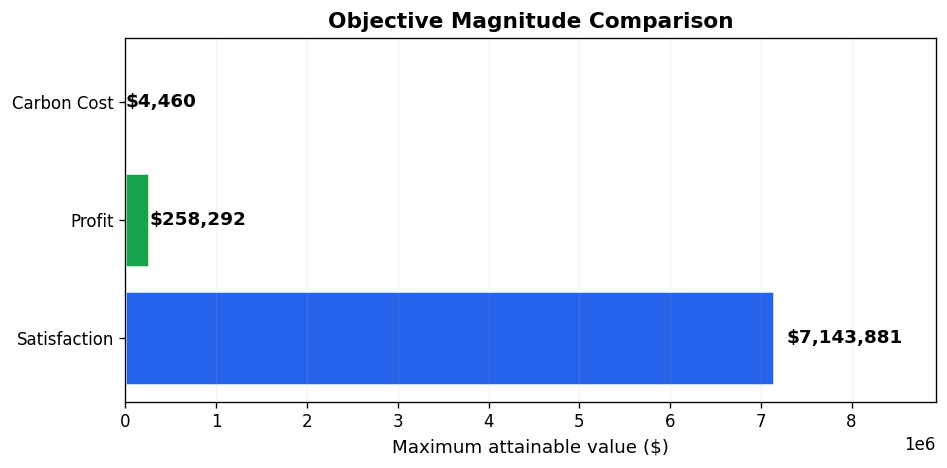

Satisfaction / Profit  = 27.7x
Profit / Carbon Cost   = 57.9x


In [70]:
obj_names = ['Satisfaction', 'Profit', 'Carbon Cost']
obj_max   = [sol_sat['objectives']['satisfaction'],
             sol_prof['objectives']['profit'],
             sol_sat['objectives']['carbon_cost']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(obj_names, obj_max,
               color=[COLORS['sat'], COLORS['prof'], COLORS['sus']],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, obj_max):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Maximum attainable value ($)')
ax.set_title('Objective Magnitude Comparison', fontweight='bold')
ax.set_xlim(0, max(obj_max)*1.25)
ax.grid(axis='x', alpha=0.15)
fig.tight_layout()
plt.show()

ratio_prof = obj_max[0] / obj_max[1] if obj_max[1] else float('inf')
ratio_carb = obj_max[1] / obj_max[2] if obj_max[2] else float('inf')
print(f"Satisfaction / Profit  = {ratio_prof:.1f}x")
print(f"Profit / Carbon Cost   = {ratio_carb:.1f}x")

**Result — Objective magnitudes are on very different scales.**
Satisfaction ($7.1M) is **27.7× larger** than profit ($258K), which is itself **57.9× larger** than carbon cost ($4.5K). This three-order-of-magnitude spread has a direct impact on weight selection: equal λ=1/3 weights do not produce a balanced trade-off — satisfaction numerically dominates. For the Chebyshev method this matters less (it normalises distances to z\*), but for linear scalarization, meaningful weight choices require either normalising each objective to [0,1] or consciously choosing λ₂ ≫ λ₁ to give profit a fair chance. For the DLENT regret bound, the dominance of satisfaction also means regret will be measured in millions of dollars, making the carbon cost term almost invisible unless explicitly amplified via the SCC multiplier.

### 7.2 - Weight sensitivity

How do objectives and acceptance rate change as we move along each weight axis?

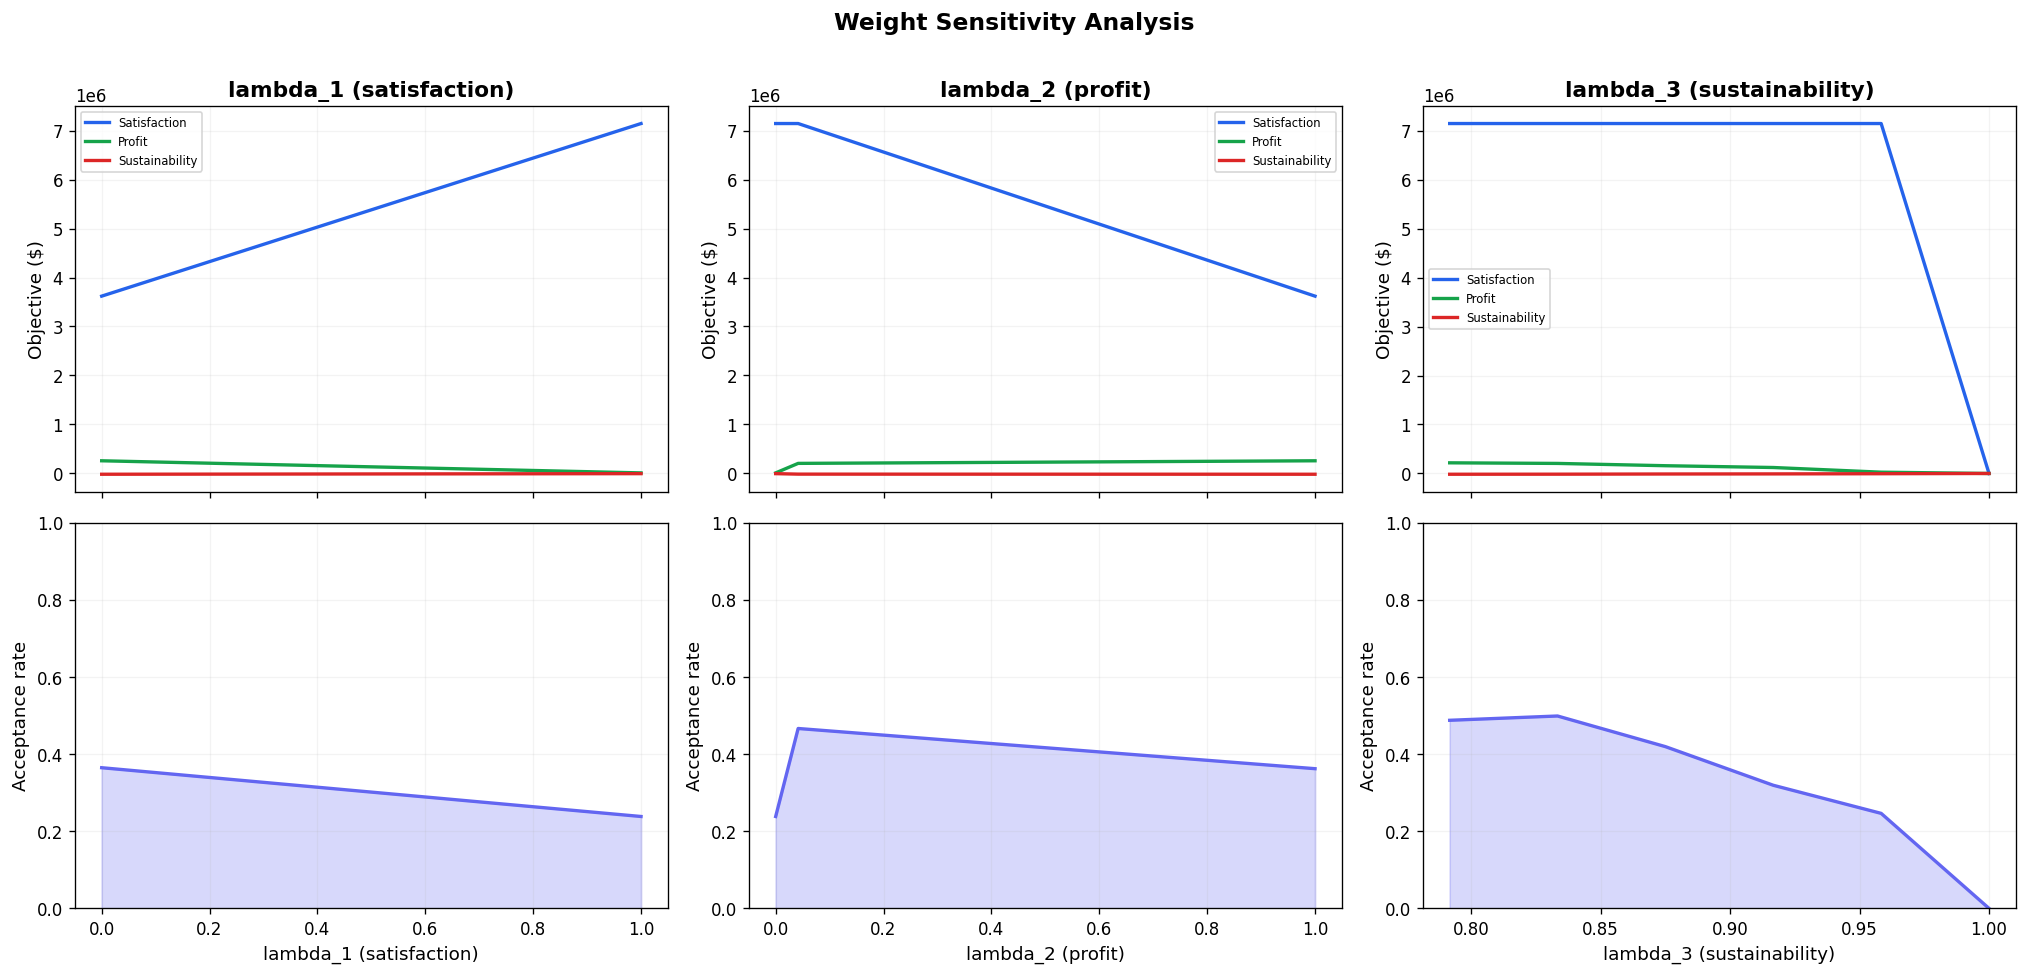

In [71]:
def sweep_single_weight(opt, axis_idx, n=25):
    results = []
    for w in np.linspace(0, 1, n):
        lam = [0.0, 0.0, 0.0]
        lam[axis_idx] = w
        remainder = 1.0 - w
        for k in range(3):
            if k != axis_idx:
                lam[k] = remainder / 2.0
        sol = opt.linear_scalarization(
            {'lambda1': lam[0], 'lambda2': lam[1], 'lambda3': lam[2]})
        if sol and sol['feasible']:
            results.append({'weight': w,
                'sat': sol['objectives']['satisfaction'],
                'prof': sol['objectives']['profit'],
                'sus': sol['objectives']['sustainability'],
                'accept': sol['acceptance_rate']})
    return pd.DataFrame(results)

labels = ['lambda_1 (satisfaction)', 'lambda_2 (profit)', 'lambda_3 (sustainability)']
sweeps = [sweep_single_weight(opt, i) for i in range(3)]

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex='col')
for col, (df, lab) in enumerate(zip(sweeps, labels)):
    if df.empty: continue
    axes[0,col].plot(df['weight'], df['sat'],  color=COLORS['sat'],  lw=2, label='Satisfaction')
    axes[0,col].plot(df['weight'], df['prof'], color=COLORS['prof'], lw=2, label='Profit')
    axes[0,col].plot(df['weight'], df['sus'],  color=COLORS['sus'],  lw=2, label='Sustainability')
    axes[0,col].set_ylabel('Objective ($)')
    axes[0,col].set_title(lab, fontweight='bold')
    axes[0,col].legend(fontsize=7); axes[0,col].grid(True, alpha=0.15)

    axes[1,col].fill_between(df['weight'], df['accept'], color=COLORS['lin'], alpha=0.25)
    axes[1,col].plot(df['weight'], df['accept'], color=COLORS['lin'], lw=2)
    axes[1,col].set_xlabel(lab); axes[1,col].set_ylabel('Acceptance rate')
    axes[1,col].set_ylim(0, 1); axes[1,col].grid(True, alpha=0.15)

fig.suptitle('Weight Sensitivity Analysis', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

**Result — Weight sensitivity: satisfaction dominates, profit is non-monotone.**
Each column sweeps one weight from 0→1 while splitting the remainder equally:
- **λ₁ sweep**: increasing the satisfaction weight causes satisfaction to jump and stay flat quickly (all high-value jobs accepted), while profit and sustainability barely change. Acceptance rate rises then plateaus — adding more satisfaction weight beyond ~0.3 brings no additional jobs.
- **λ₂ sweep**: profit increases monotonically as more weight is given to margin. Satisfaction actually *decreases* — the LP switches to lower-value but higher-margin jobs. Acceptance rate is relatively stable (~36%).
- **λ₃ sweep**: as sustainability weight increases, all objectives collapse toward zero and the acceptance rate drops sharply toward 0%. This confirms that λ₃ is a "suppressor" — adding it always reduces what gets scheduled. In practice, λ₃ should be kept small (or replaced by a carbon-per-job budget in the ε-constraint formulation).

### 7.3 - Accepted-job profile

What do the accepted jobs look like under each extreme operating mode?

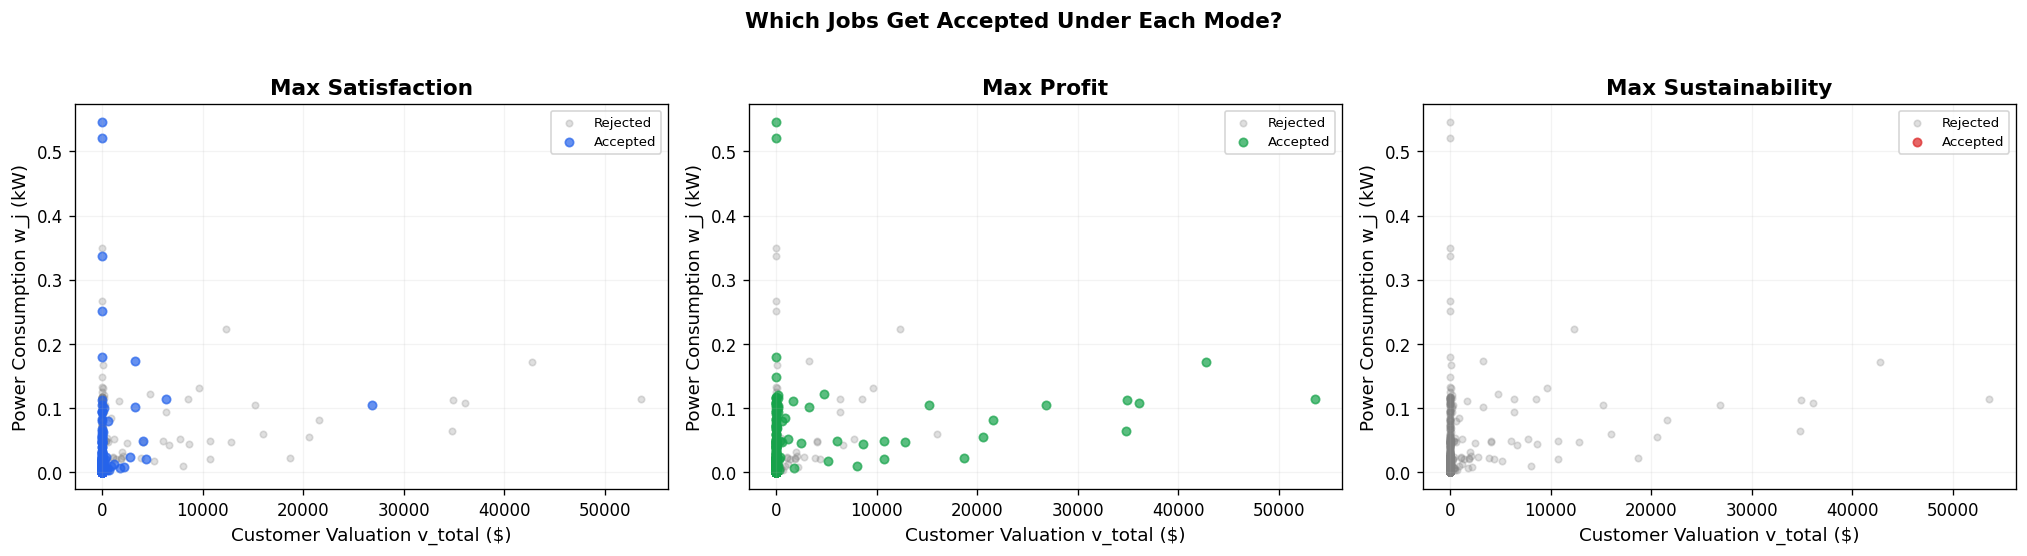

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (sol, label, clr) in zip(axes,
    [(sol_sat, 'Max Satisfaction', COLORS['sat']),
     (sol_prof,'Max Profit',       COLORS['prof']),
     (sol_sus, 'Max Sustainability',COLORS['sus'])]):
    accepted = jobs_df.iloc[sol['x'].astype(bool)]
    rejected = jobs_df.iloc[~sol['x'].astype(bool)]
    ax.scatter(rejected['v_total'], rejected['w_j_kw'],
               s=15, alpha=0.25, color='grey', label='Rejected')
    ax.scatter(accepted['v_total'], accepted['w_j_kw'],
               s=25, alpha=0.7, color=clr, label='Accepted')
    ax.set_xlabel('Customer Valuation v_total ($)')
    ax.set_ylabel('Power Consumption w_j (kW)')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.15)
fig.suptitle('Which Jobs Get Accepted Under Each Mode?',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

**Result — Each mode selects structurally different jobs.**
Each panel plots all 1,977 jobs in (valuation, power) space, with accepted jobs coloured and rejected in grey:
- **Max Satisfaction** (blue): accepts high-valuation jobs regardless of power draw — you see blue dots spread across the full power range at the right side of the x-axis. Power-hungry jobs are not penalised.
- **Max Profit** (green): accepts jobs with high margin (phi − C_elec), which are not necessarily high-valuation. The accepted cluster shifts left (lower v_total) but also toward lower power (lower C_elec = lower electricity cost = higher margin). The LP is effectively selecting "efficient" jobs.
- **Max Sustainability** (red): accepts nothing — 0% acceptance — confirming the degeneracy discussed earlier.

---
## 8 — Summary & Recommendations

### Fluid Volume vs. Temporal Constraints

| Fluid Volume (OPT_LP) | Temporal (instantaneous) |
|----------------------|--------------------------|
| 2 constraints total | 2 × n_slots constraints (sparse) |
| Fast, scalable LP | Large sparse LP |
| Theoretical benchmark for regret bounds | Closer to physical reality |
| Slight over-approximation of feasible set | Exact feasibility check |

The Fluid LP is the correct baseline for DLENT Regret analysis: it gives the offline optimal under a relaxed constraint, producing an upper bound that defines the regret denominator.

### Key findings

| Finding | Detail |
|---------|--------|
| **Pareto front** | Check the verdict cell above |
| **Fluid constraints** | 2 rows: total CPU-hours and RAM-hours volume budgets |
| **Acceptance rate** | Driven by volume utilisation across all jobs |

### Implications for the dynamic online system

1. **OPT_LP** (this notebook) provides the theoretical offline ceiling — the benchmark for computing DLENT Regret.
2. Use the Pareto front to understand objective trade-offs before selecting λ weights for the online mechanism.
3. **Linear scalarization** is sufficient if the front is convex; otherwise use Chebyshev.
4. In the dynamic version, track cumulative resource volumes consumed and compare against `c_i × T_remaining` to determine admission feasibility.